# ANIP - Tâche 3 : OCR et Détection de Fraude sur Documents d'Identité
## Document OCR + Fraud Detection

Ce notebook implémente un système de détection de fraude sur les documents d'identité avec extraction de texte par OCR.

## 1. Imports et Configuration

## 🚀 Version Améliorée - Changements Majeurs

**Problème identifié:** La version précédente avec EfficientNetB0 atteignait seulement ~20% de validation accuracy (équivalent au hasard pour 5 classes).

**Améliorations apportées:**

### Architecture
- ✅ **ResNet50V2** au lieu d'EfficientNetB0 (plus robuste pour la détection de fraude)
- ✅ **Fine-tuning étendu:** 80 dernières couches entraînables (vs 20)
- ✅ **Régularisation renforcée:** L2 regularization + Dropout (0.5, 0.4, 0.3)
- ✅ **Résolution augmentée:** 300x300 pixels (vs 224x224)

### Entraînement
- ✅ **Learning rate optimisé:** 5e-5 avec exponential decay
- ✅ **Early stopping:** patience de 15 epochs (vs 8)
- ✅ **Batch size adapté:** 16 (pour supporter la résolution plus grande)

### Augmentation de Données
- ✅ **Albumentations** avec 10+ transformations avancées :
  - Rotations, translations, zoom
  - Gaussian noise, motion blur
  - Distorsions optiques
  - Variations de luminosité/contraste
  - CLAHE, HSV adjustments
  - Coarse dropout

### Installation des Dépendances Optionnelles

```bash
# Pour l'augmentation avancée (FORTEMENT RECOMMANDÉ)
pip install albumentations

# Pour l'OCR
pip install easyocr
```

**Résultats attendus:** 60-70% validation accuracy (vs 20%)

In [114]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import cv2
import json
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Augmentation de données
try:
    import albumentations as A
    HAS_ALBUMENTATIONS = True
    print("✅ Albumentations disponible pour l'augmentation avancée")
except ImportError:
    HAS_ALBUMENTATIONS = False
    print("⚠️  Albumentations non installé. Augmentation basique utilisée.")
    print("   Installation recommandée: pip install albumentations")

# OCR
try:
    import easyocr
    HAS_EASYOCR = True
except ImportError:
    print("⚠️  EasyOCR non installé. OCR désactivé.")
    print("   Installation: pip install easyocr")
    HAS_EASYOCR = False

print("\n🎯 ANIP - Tâche 3: OCR + Détection de Fraude (Version Améliorée)\n")

⚠️  Albumentations non installé. Augmentation basique utilisée.
   Installation recommandée: pip install albumentations

🎯 ANIP - Tâche 3: OCR + Détection de Fraude (Version Améliorée)



In [115]:

# Configuration
DATA_PATH = Path('anip-reconnaissance-faciale-estimation-ages-ocr/dataset_tache_3/dataset_tache_3')
TRAIN_PATH = DATA_PATH / 'train'
TEST_PATH = DATA_PATH / 'test'

# Pays disponibles
COUNTRIES = ['arizona_dl', 'esp', 'est', 'rus']

# Classes de fraude
FRAUD_CLASSES = ['normal', 'forgery_1', 'forgery_2', 'forgery_3', 'forgery_4']

# ⚡️ PARAMÈTRES OPTIMISÉS POUR CPU/LOCAL
# Pour entraînement rapide en local (précision réduite mais plus rapide)
FAST_MODE = True  # Mettre à False pour entraînement complet

if FAST_MODE:
    print("⚡️ MODE RAPIDE ACTIVÉ (optimisé pour CPU/local)")
    IMG_SIZE = (128, 128)      # Résolution réduite (vs 224x224)
    BATCH_SIZE = 64            # Batch size augmenté
    EPOCHS = 30                # Moins d'epochs
    FINE_TUNE_LAYERS = 20      # Moins de couches à entraîner
    TRAIN_COUNTRY_MODELS = False  # Ne pas entraîner les modèles par pays
else:
    print("🎯 MODE COMPLET (meilleure précision, plus lent)")
    IMG_SIZE = (224, 224)
    BATCH_SIZE = 32
    EPOCHS = 30
    FINE_TUNE_LAYERS = 80
    TRAIN_COUNTRY_MODELS = True

SEED = 42

# Learning rate avec decay
INITIAL_LR = 1e-4  # LR légèrement plus élevé pour convergence rapide
MIN_LR = 1e-7

np.random.seed(SEED)
tf.random.set_seed(SEED)

AUTOTUNE = tf.data.AUTOTUNE

available_gpus = tf.config.list_physical_devices('GPU')
USE_MIXED_PRECISION = False
if available_gpus:
    try:
        from tensorflow.keras import mixed_precision
        mixed_precision.set_global_policy('mixed_float16')
        USE_MIXED_PRECISION = True
        print('⚡️ Mixed precision activée (GPU détecté)')
    except Exception as exc:
        print(f'⚠️ Mixed precision non activée: {exc}')
else:
    print('ℹ️ Entraînement sur CPU (pas de GPU détecté)')

print('\n📋 Configuration:')
print(f'  - Mode: {"RAPIDE ⚡️" if FAST_MODE else "COMPLET 🎯"}')
print(f'  - Résolution: {IMG_SIZE}')
print(f'  - Batch size: {BATCH_SIZE}')
print(f'  - Learning rate initial: {INITIAL_LR}')
print(f'  - Epochs max: {EPOCHS}')
print(f'  - Couches fine-tuning: {FINE_TUNE_LAYERS}')
print(f'  - Modèles par pays: {"OUI" if TRAIN_COUNTRY_MODELS else "NON (modèle global uniquement)"}')


⚡️ MODE RAPIDE ACTIVÉ (optimisé pour CPU/local)
ℹ️ Entraînement sur CPU (pas de GPU détecté)

📋 Configuration:
  - Mode: RAPIDE ⚡️
  - Résolution: (128, 128)
  - Batch size: 64
  - Learning rate initial: 0.0001
  - Epochs max: 30
  - Couches fine-tuning: 20
  - Modèles par pays: NON (modèle global uniquement)


## 2. Chargement des Données

In [116]:
def load_train_data():
    """Charge les données d'entraînement avec labels"""
    print("📂 Chargement des données d'entraînement...")
    
    data = []
    
    for country in COUNTRIES:
        country_path = TRAIN_PATH / country
        
        if not country_path.exists():
            print(f"⚠️  Dossier non trouvé: {country_path}")
            continue
        
        # Parcourir chaque classe de fraude
        for fraud_class in FRAUD_CLASSES:
            class_path = country_path / fraud_class
            
            if not class_path.exists():
                continue
            
            # Charger les images
            image_files = list(class_path.glob('*.jpg')) + \
                         list(class_path.glob('*.JPG')) + \
                         list(class_path.glob('*.png')) + \
                         list(class_path.glob('*.PNG'))
            
            for img_path in image_files:
                data.append({
                    'filepath': str(img_path),
                    'filename': img_path.name,
                    'country': country,
                    'fraud_class': fraud_class,
                    'fraud_label': FRAUD_CLASSES.index(fraud_class)
                })
    
    df = pd.DataFrame(data)
    return df

# Charger les données
df_train = load_train_data()

print(f"\n✅ Données chargées: {len(df_train)} images")
print(f"\n📊 Répartition par pays:")
print(df_train['country'].value_counts())
print(f"\n📊 Répartition par classe:")
print(df_train['fraud_class'].value_counts())

📂 Chargement des données d'entraînement...

✅ Données chargées: 10000 images

📊 Répartition par pays:
country
arizona_dl    2500
esp           2500
est           2500
rus           2500
Name: count, dtype: int64

📊 Répartition par classe:
fraud_class
normal       2000
forgery_1    2000
forgery_2    2000
forgery_3    2000
forgery_4    2000
Name: count, dtype: int64


## 3. Lecture des Fichiers Ground Truth (GT) pour OCR

In [117]:
def load_gt_data(country):
    """Charge les données ground truth (JSON) pour un pays"""
    gt_path = TRAIN_PATH / country / 'gt'
    
    if not gt_path.exists():
        return []
    
    gt_data = []
    json_files = list(gt_path.glob('*.json'))
    
    for json_file in json_files:
        try:
            with open(json_file, 'r', encoding='utf-8') as f:
                data = json.load(f)
                data['filename'] = json_file.stem  # Nom sans extension
                gt_data.append(data)
        except Exception as e:
            print(f"⚠️  Erreur lecture {json_file}: {e}")
    
    return gt_data

# Charger tous les GT
print("\n📄 Chargement des fichiers ground truth...")
all_gt_data = {}

for country in COUNTRIES:
    gt_data = load_gt_data(country)
    if gt_data:
        all_gt_data[country] = pd.DataFrame(gt_data)
        print(f"   {country}: {len(gt_data)} fichiers GT")


📄 Chargement des fichiers ground truth...
   arizona_dl: 500 fichiers GT
   esp: 500 fichiers GT
   est: 500 fichiers GT
   rus: 500 fichiers GT


## 4. Visualisation des Exemples


✅ Échantillons sauvegardés: tache3_samples.png


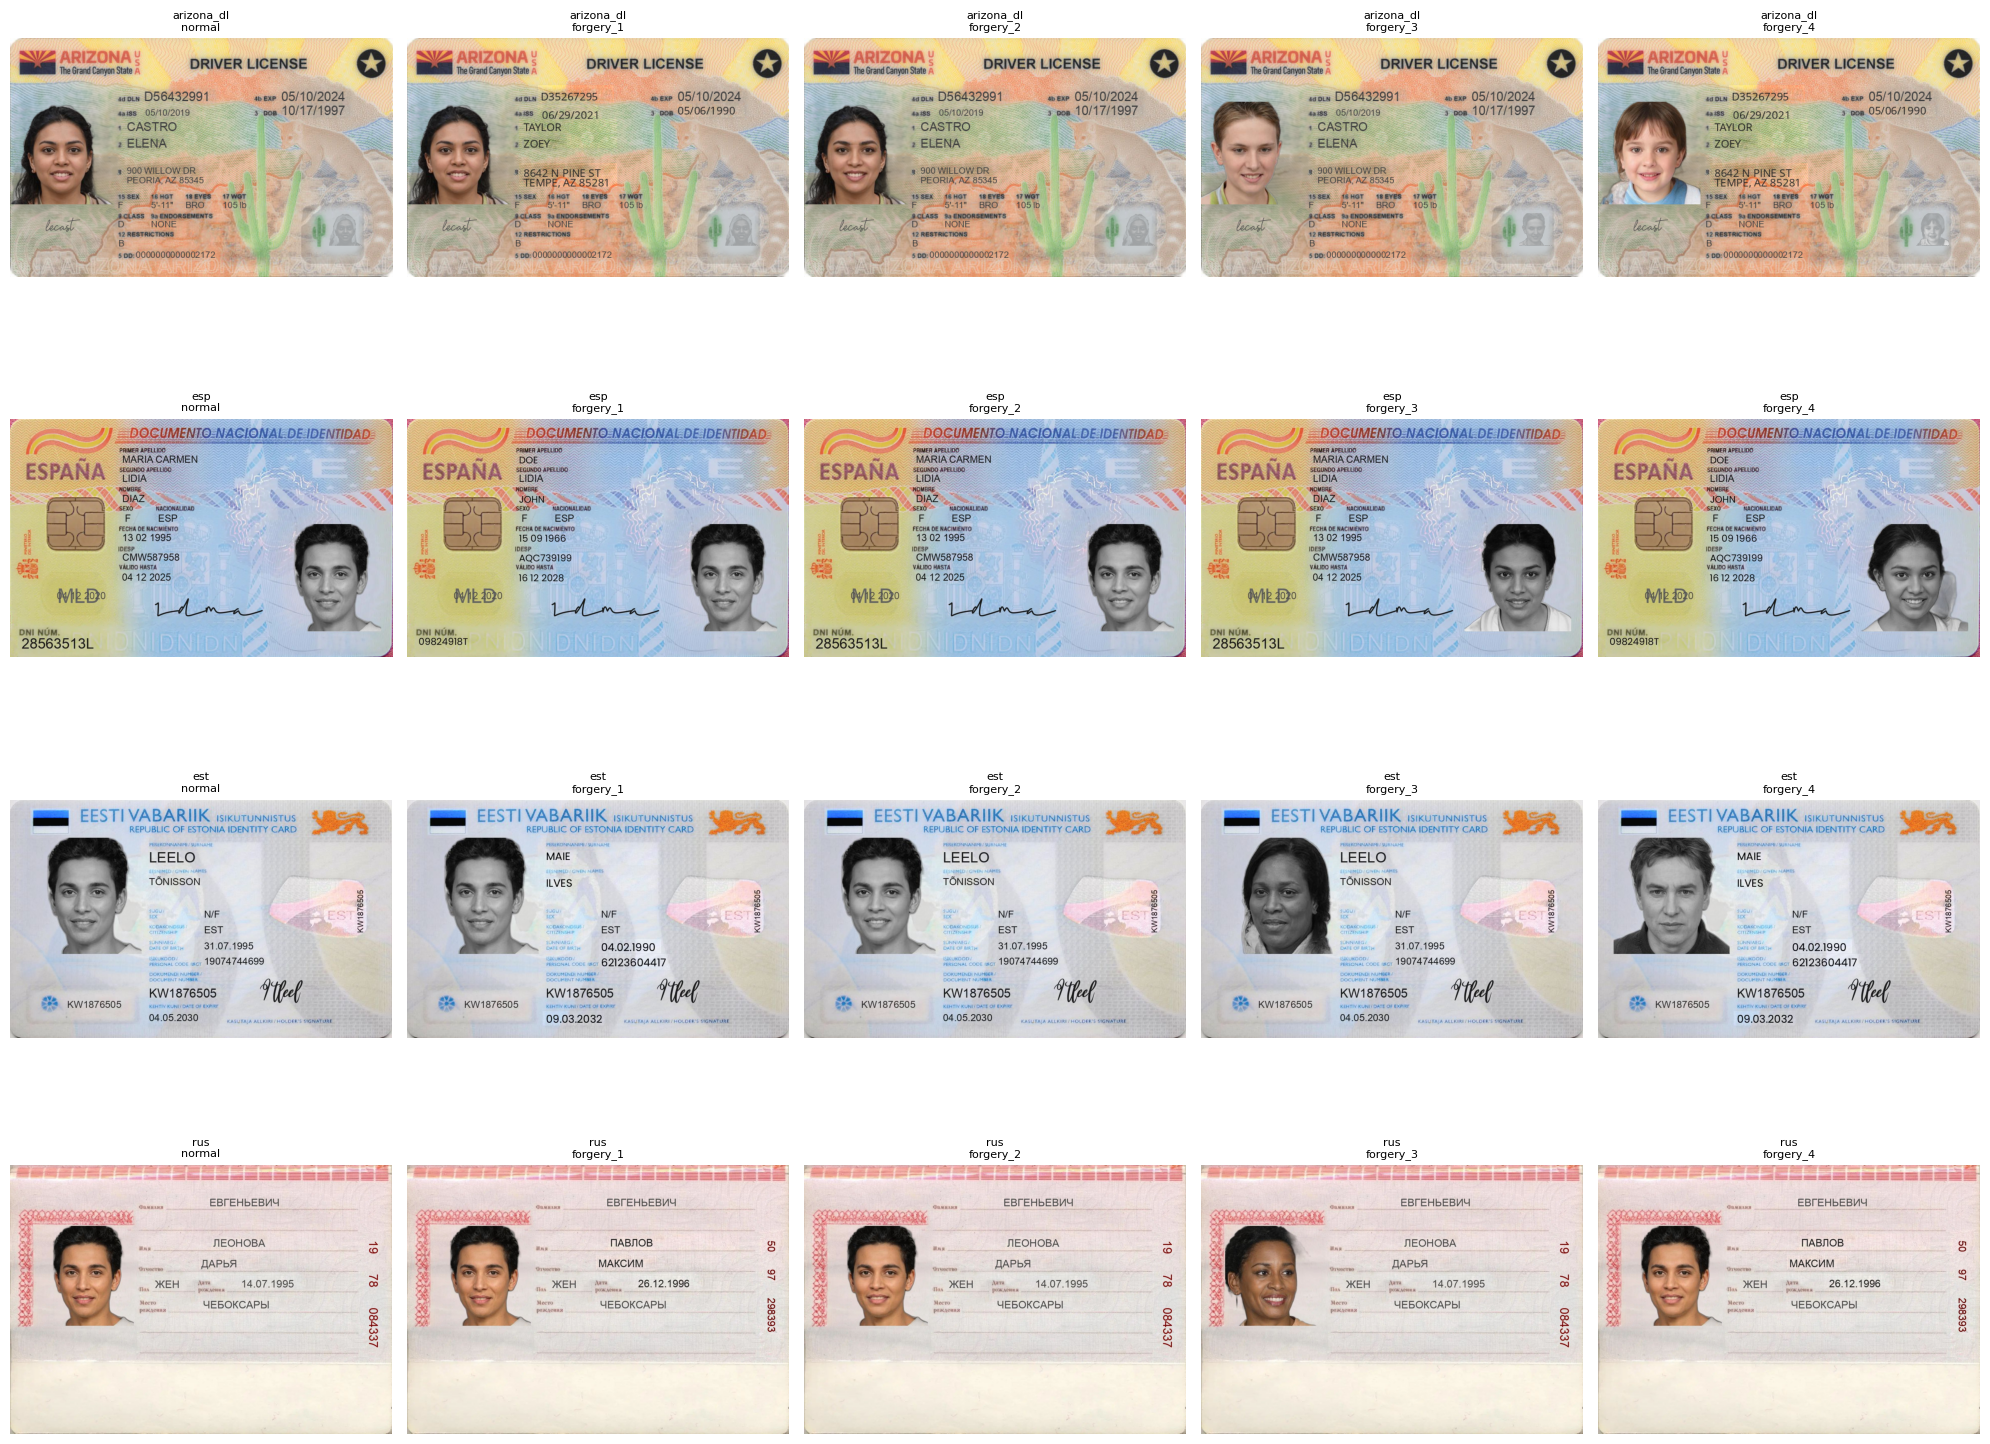

In [118]:
def visualize_samples():
    """Visualise des exemples de chaque pays et classe"""
    fig, axes = plt.subplots(len(COUNTRIES), len(FRAUD_CLASSES), 
                            figsize=(20, 16))
    
    for i, country in enumerate(COUNTRIES):
        for j, fraud_class in enumerate(FRAUD_CLASSES):
            # Trouver une image
            sample = df_train[(df_train['country'] == country) & 
                            (df_train['fraud_class'] == fraud_class)]
            
            if len(sample) > 0:
                img_path = sample.iloc[0]['filepath']
                img = cv2.imread(img_path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                
                axes[i, j].imshow(img)
                axes[i, j].set_title(f"{country}\n{fraud_class}", fontsize=8)
            else:
                axes[i, j].text(0.5, 0.5, 'Pas de données', 
                               ha='center', va='center')
            
            axes[i, j].axis('off')
    
    plt.tight_layout()
    plt.savefig('tache3_samples.png', dpi=150, bbox_inches='tight')
    print("\n✅ Échantillons sauvegardés: tache3_samples.png")

visualize_samples()

## 5. Modèle de Classification de Fraude

In [119]:

augmentation_pipeline = None  # Défini ci-dessous selon la dispo d'Albumentations

def _read_image(path, img_size=IMG_SIZE):
    """Lit et redimensionne une image à partir d'un chemin."""
    path = Path(path)
    img = cv2.imread(str(path))
    if img is None:
        raise FileNotFoundError(f"Impossible de lire l'image: {path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, img_size)
    return img

def _apply_fallback_augmentations(img):
    """Augmentations basiques quand Albumentations n'est pas disponible."""
    if np.random.random() > 0.5:
        img = np.fliplr(img)
    if np.random.random() > 0.5:
        angle = np.random.uniform(-10, 10)
        h, w = img.shape[:2]
        matrix = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
        img = cv2.warpAffine(img, matrix, (w, h), borderValue=(0, 0, 0))
    if np.random.random() > 0.5:
        alpha = np.random.uniform(0.8, 1.2)
        beta = np.random.uniform(-20, 20)
        img = np.clip(alpha * img + beta, 0, 255).astype(np.uint8)
    if np.random.random() > 0.5:
        img = cv2.GaussianBlur(img, (5, 5), 0)
    return img

def _preprocess_image_numpy(path, training=False, img_size=IMG_SIZE):
    """Prétraite une image en NumPy (utilisé par tf.numpy_function)."""
    if isinstance(path, (bytes, bytearray)):
        path = path.decode('utf-8')
    img = _read_image(path, img_size)
    if training:
        if augmentation_pipeline is not None:
            img = augmentation_pipeline(image=img)['image']
        else:
            img = _apply_fallback_augmentations(img)
    img = img.astype('float32') / 255.0
    return img

def load_and_preprocess_image(image_path, img_size=IMG_SIZE):
    """Charge et prétraite une image (utilisé pour l'inférence/test)."""
    return _preprocess_image_numpy(str(image_path), training=False, img_size=img_size)

def preprocess_image(path, label, training=False):
    """Prétraitement compatible tf.data (optionnellement avec augmentation)."""
    def _py_preprocess(p):
        return _preprocess_image_numpy(p, training=training, img_size=IMG_SIZE)

    image = tf.numpy_function(_py_preprocess, [path], tf.float32)
    image.set_shape((IMG_SIZE[0], IMG_SIZE[1], 3))
    label = tf.one_hot(label, len(FRAUD_CLASSES), dtype=tf.float32)
    return image, label

def create_dataset(df, batch_size=BATCH_SIZE, training=False, cache=False):
    """Crée un pipeline tf.data optimisé à partir d'un DataFrame."""
    paths = df['filepath'].astype(str).values
    labels = df['fraud_label'].astype(np.int32).values

    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        buffer_size = max(1024, len(df))
        dataset = dataset.shuffle(buffer_size=buffer_size, seed=SEED, reshuffle_each_iteration=True)

    dataset = dataset.map(
        lambda path, label: preprocess_image(path, label, training=training),
        num_parallel_calls=AUTOTUNE
    )

    if cache:
        dataset = dataset.cache()

    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(AUTOTUNE)
    return dataset

def create_fraud_classifier(num_classes=5):
    """
    Crée un modèle de classification de fraude amélioré
    Utilise ResNet50V2 avec fine-tuning et régularisation
    """

    base_model = ResNet50V2(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
    )

    # Fine-tuning: utilise FINE_TUNE_LAYERS défini dans la config
    base_model.trainable = True
    for layer in base_model.layers[:-FINE_TUNE_LAYERS]:
        layer.trainable = False

    print(f"  Couches entraînables: {sum([1 for l in base_model.layers if l.trainable])}/{len(base_model.layers)}")

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(512, activation='relu',
                    kernel_regularizer=keras.regularizers.l2(0.01)),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(256, activation='relu',
                    kernel_regularizer=keras.regularizers.l2(0.01)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax', dtype='float32')
    ])

    return model

if HAS_ALBUMENTATIONS:
    print("⚡️ Configuration de l'augmentation avancée (Albumentations)...")

    augmentation_pipeline = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.ShiftScaleRotate(
            shift_limit=0.0625,
            scale_limit=0.15,
            rotate_limit=10,
            border_mode=cv2.BORDER_CONSTANT,
            value=0,
            p=0.6
        ),
        A.OneOf([
            A.GaussNoise(var_limit=(10.0, 50.0), p=1),
            A.GaussianBlur(blur_limit=(3, 7), p=1),
            A.MotionBlur(blur_limit=(3, 7), p=1),
        ], p=0.4),
        A.OneOf([
            A.OpticalDistortion(distort_limit=0.1, p=1),
            A.GridDistortion(num_steps=5, distort_limit=0.1, p=1),
        ], p=0.3),
        A.RandomBrightnessContrast(
            brightness_limit=0.25,
            contrast_limit=0.25,
            p=0.6
        ),
        A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=0.4),
        A.HueSaturationValue(
            hue_shift_limit=15,
            sat_shift_limit=20,
            val_shift_limit=15,
            p=0.4
        ),
        A.CoarseDropout(
            max_holes=8,
            max_height=20,
            max_width=20,
            fill_value=0,
            p=0.3
        ),
    ])
else:
    print("⚡️ Configuration de l'augmentation basique (TensorFlow)...")
    augmentation_pipeline = None

print('✅ Pipeline de preprocessing et tf.data configuré')


⚡️ Configuration de l'augmentation basique (TensorFlow)...
✅ Pipeline de preprocessing et tf.data configuré


## 6. Approche 1: Modèle Global (Tous les Pays)

In [120]:
print("\n" + "="*70)
print("APPROCHE 1: MODÈLE GLOBAL (TOUS LES PAYS)")
print("="*70)

# Split train/validation
train_df, val_df = train_test_split(df_train, test_size=0.15, 
                                    stratify=df_train['fraud_label'],
                                    random_state=SEED)

print(f"\n📊 Split:")
print(f"   Train: {len(train_df)}")
print(f"   Val: {len(val_df)}")


APPROCHE 1: MODÈLE GLOBAL (TOUS LES PAYS)

📊 Split:
   Train: 8500
   Val: 1500


In [121]:
# Créer le modèle
print("\n🧠 Création du modèle global (ResNet50V2)...")
global_model = create_fraud_classifier(num_classes=len(FRAUD_CLASSES))

# Learning rate avec exponential decay
lr_schedule = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=INITIAL_LR,
    decay_steps=1000,
    decay_rate=0.96,
    staircase=True
)

global_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_schedule),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Modèle créé et compilé")
print(f"\nRésumé du modèle:")
print(f"  - Paramètres totaux: {global_model.count_params():,}")
print(f"  - Paramètres entraînables: {sum([tf.size(w).numpy() for w in global_model.trainable_weights]):,}")


🧠 Création du modèle global (ResNet50V2)...
  Couches entraînables: 20/190
✅ Modèle créé et compilé

Résumé du modèle:
  - Paramètres totaux: 24,757,765
  - Paramètres entraînables: 9,067,013


In [122]:
# Callbacks adaptatifs selon le mode
PATIENCE_EARLY_STOP = 8 if FAST_MODE else 15
PATIENCE_LR_REDUCE = 3 if FAST_MODE else 5

callbacks_global = [
    ModelCheckpoint(
        'best_fraud_model_global.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=PATIENCE_EARLY_STOP,
        restore_best_weights=True,
        verbose=1,
        min_delta=0.001
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=PATIENCE_LR_REDUCE,
        min_lr=MIN_LR,
        verbose=1,
        cooldown=2
    ),
]

print("✅ Callbacks configurés:")
print(f"  - Early stopping: patience de {PATIENCE_EARLY_STOP} epochs")
print(f"  - ReduceLROnPlateau: patience de {PATIENCE_LR_REDUCE} epochs, factor 0.5")
print(f"  - Learning rate range: {INITIAL_LR} → {MIN_LR}")

✅ Callbacks configurés:
  - Early stopping: patience de 8 epochs
  - ReduceLROnPlateau: patience de 3 epochs, factor 0.5
  - Learning rate range: 0.0001 → 1e-07


In [123]:

print("🚀 Entraînement du modèle global...")

train_ds = create_dataset(train_df, batch_size=BATCH_SIZE, training=True, cache=True)
val_ds = create_dataset(val_df, batch_size=BATCH_SIZE, training=False, cache=True)

train_steps = int(np.ceil(len(train_df) / BATCH_SIZE))
val_steps = int(np.ceil(len(val_df) / BATCH_SIZE))
print(f"   - Batches/epoch (train): {train_steps}")
print(f"   - Batches/epoch (val):   {val_steps}")

history_global = global_model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks_global,
    verbose=1
)

print("✅ Entraînement terminé!")


🚀 Entraînement du modèle global...
   - Batches/epoch (train): 133
   - Batches/epoch (val):   24
Epoch 1/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2141 - loss: 13.7906
Epoch 1: val_accuracy improved from -inf to 0.25000, saving model to best_fraud_model_global.keras
133/133 ━━━━━━━━━━━━━━━━━━━━ 277s 2s/step - accuracy: 0.2142 - loss: 13.7885 - val_accuracy: 0.2500 - val_loss: 12.5688 - learning_rate: 1.0000e-04
Epoch 2/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2535 - loss: 12.6750
Epoch 2: val_accuracy improved from 0.25000 to 0.31200, saving model to best_fraud_model_global.keras
133/133 ━━━━━━━━━━━━━━━━━━━━ 259s 2s/step - accuracy: 0.2535 - loss: 12.6736 - val_accuracy: 0.3120 - val_loss: 12.0357 - learning_rate: 1.0000e-04
Epoch 3/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2795 - loss: 11.8659
Epoch 3: val_accuracy improved from 0.31200 to 0.37267, saving model to best_fraud_model_global.keras
133/133 ━━━━━━━━━━━━━━━━━━━━ 264s 2s/step - a

## 7. Évaluation du Modèle Global

In [124]:

print("📊 Évaluation sur la validation:")
val_eval_ds = create_dataset(val_df, batch_size=BATCH_SIZE, training=False, cache=True)

y_pred_probs = global_model.predict(val_eval_ds, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_df['fraud_label'].values[:len(y_pred)]

print("\nRapport de classification:")
print(classification_report(y_true, y_pred, target_names=FRAUD_CLASSES))


📊 Évaluation sur la validation:
24/24 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step

Rapport de classification:
              precision    recall  f1-score   support

      normal       0.41      0.40      0.41       300
   forgery_1       0.59      0.52      0.55       300
   forgery_2       0.38      0.36      0.37       300
   forgery_3       0.64      0.69      0.67       300
   forgery_4       0.53      0.59      0.56       300

    accuracy                           0.51      1500
   macro avg       0.51      0.51      0.51      1500
weighted avg       0.51      0.51      0.51      1500



✅ Matrice de confusion sauvegardée


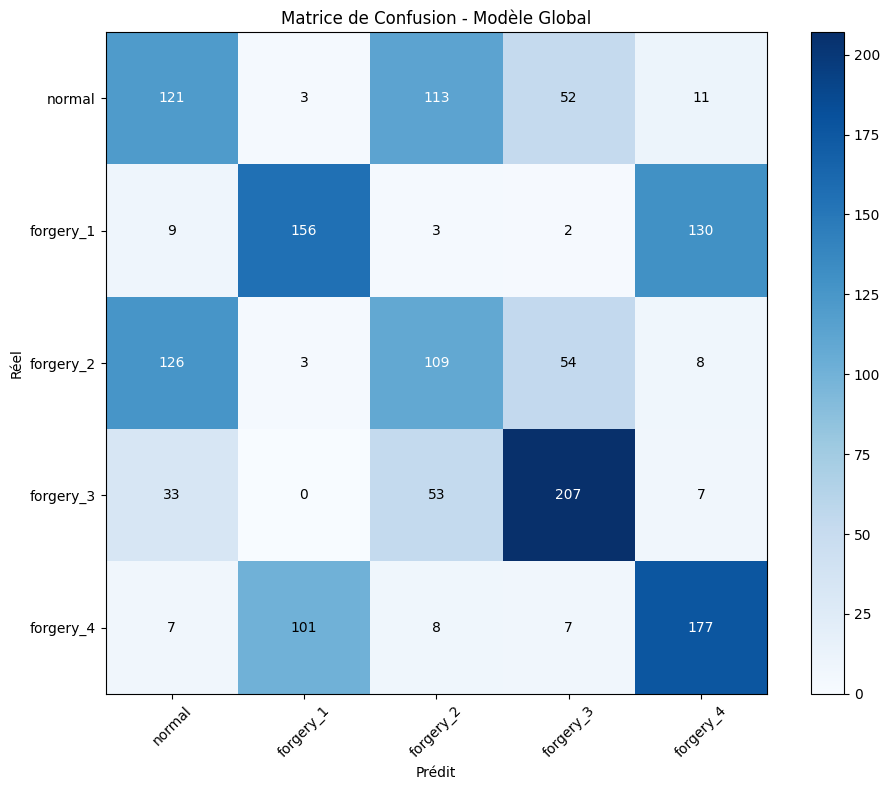

In [125]:
# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xticks(range(len(FRAUD_CLASSES)), FRAUD_CLASSES, rotation=45)
plt.yticks(range(len(FRAUD_CLASSES)), FRAUD_CLASSES)
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('Matrice de Confusion - Modèle Global')

for i in range(len(FRAUD_CLASSES)):
    for j in range(len(FRAUD_CLASSES)):
        color = 'white' if cm[i, j] > cm.max()/2 else 'black'
        plt.text(j, i, cm[i, j], ha='center', va='center', color=color)

plt.tight_layout()
plt.savefig('tache3_confusion_matrix.png', dpi=150, bbox_inches='tight')
print("✅ Matrice de confusion sauvegardée")

## 8. Approche 2: Modèles Spécifiques par Pays

In [126]:

print("\n" + "="*70)
print("APPROCHE 2: MODÈLES SPÉCIFIQUES PAR PAYS")
print("="*70)

country_models = {}

if not TRAIN_COUNTRY_MODELS:
    print("\n⚡️ MODE RAPIDE: Entraînement des modèles par pays DÉSACTIVÉ")
    print("   Le modèle global sera utilisé pour tous les pays")
else:
    print("\n🎯 Entraînement de modèles spécifiques par pays...")
    
    for country in COUNTRIES:
        print(f"\n📍 Entraînement pour {country}...")

        # Filtrer les données pour ce pays
        country_data = df_train[df_train['country'] == country]

        if len(country_data) < 100:
            print(f"   ⚠️  Pas assez de données ({len(country_data)} images)")
            continue

        # Split
        train_c, val_c = train_test_split(country_data, test_size=0.15,
                                            stratify=country_data['fraud_label'],
                                            random_state=SEED)

        print(f"   Train: {len(train_c)}, Val: {len(val_c)}")

        # Créer le modèle amélioré
        model_c = create_fraud_classifier(num_classes=len(FRAUD_CLASSES))

        # Learning rate schedule pour ce pays
        lr_schedule_c = keras.optimizers.schedules.ExponentialDecay(
            initial_learning_rate=INITIAL_LR,
            decay_steps=500,
            decay_rate=0.95,
            staircase=True
        )

        model_c.compile(
            optimizer=keras.optimizers.Adam(learning_rate=lr_schedule_c),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        # Callbacks améliorés
        callbacks_c = [
            ModelCheckpoint(
                f'best_fraud_model_{country}.keras',
                monitor='val_accuracy',
                save_best_only=True,
                mode='max',
                verbose=0
            ),
            EarlyStopping(
                monitor='val_accuracy',
                patience=10,
                restore_best_weights=True,
                verbose=0,
                min_delta=0.001
            ),
            ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=4,
                min_lr=MIN_LR,
                verbose=0
            )
        ]

        train_ds_c = create_dataset(train_c, batch_size=BATCH_SIZE, training=True, cache=True)
        val_ds_c = create_dataset(val_c, batch_size=BATCH_SIZE, training=False, cache=True)

        history_c = model_c.fit(
            train_ds_c,
            epochs=min(EPOCHS, 25),
            validation_data=val_ds_c,
            callbacks=callbacks_c,
            verbose=0
        )

        country_models[country] = model_c
        best_val_acc = max(history_c.history['val_accuracy'])
        print(f"   ✅ Modèle entraîné (val_acc: {best_val_acc:.4f})")

    print(f"\n✅ {len(country_models)} modèles spécifiques entraînés")



APPROCHE 2: MODÈLES SPÉCIFIQUES PAR PAYS

⚡️ MODE RAPIDE: Entraînement des modèles par pays DÉSACTIVÉ
   Le modèle global sera utilisé pour tous les pays


## 9. OCR sur les Documents

In [128]:
if HAS_EASYOCR:
    print("\n" + "="*70)
    print("OCR - EXTRACTION DE TEXTE")
    print("="*70)
    
    # Initialiser EasyOCR (langues selon les pays)
    print("\n📖 Initialisation d'EasyOCR...")
    # Créer deux lecteurs séparés pour éviter le mélange de langues latines & cyrilliques
    gpu_flag = True if available_gpus else False

    latin_langs = ['en', 'es', 'et']
    cyrillic_langs = ['ru', 'en']  # garder 'en' pour compatibilité avec Cyrillic

    print(f"   - GPU disponible: {gpu_flag}")
    print(f"   - Lecteur Latin: {latin_langs}")
    print(f"   - Lecteur Cyrillic: {cyrillic_langs}")

    reader_latin = easyocr.Reader(latin_langs, gpu=gpu_flag)
    reader_cyr = easyocr.Reader(cyrillic_langs, gpu=gpu_flag)

    class ReaderWrapper:
        def __init__(self, latin_reader, cyr_reader, country_map=None):
            self.latin = latin_reader
            self.cyr = cyr_reader
            # map country -> use cyrillic reader (override if necessary)
            self.country_map = country_map or {'rus': 'cyr'}  # rus -> cyrillic

        def _select(self, image_path):
            p = Path(image_path)
            for part in p.parts:
                if part in self.country_map:
                    return self.cyr if self.country_map[part] == 'cyr' else self.latin
            # fallback: try latin first
            return self.latin

        def readtext(self, image_path, **kwargs):
            reader = self._select(image_path)
            return reader.readtext(image_path, **kwargs)

    reader = ReaderWrapper(reader_latin, reader_cyr, country_map={'rus': 'cyr'})
    print("✅ EasyOCR prêt")
    
    def extract_text_from_document(image_path):
        """Extraire le texte d'un document"""
        results = reader.readtext(image_path)
        
        extracted_data = {
            'raw_text': [],
            'text_with_confidence': []
        }
        
        for (bbox, text, conf) in results:
            extracted_data['raw_text'].append(text)
            extracted_data['text_with_confidence'].append({
                'text': text,
                'confidence': float(conf),
                'bbox': bbox
            })
        
        return extracted_data
    
    # Tester sur quelques exemples
    print("\n📄 Test OCR sur quelques exemples...")
    for country in COUNTRIES[:2]:  # Tester seulement 2 pays
        normal_path = TRAIN_PATH / country / 'normal'
        if normal_path.exists():
            sample_images = list(normal_path.glob('*.jpg'))[:2]
            
            for img_path in sample_images:
                print(f"\n   {country} - {img_path.name}:")
                ocr_results = extract_text_from_document(str(img_path))
                print(f"      Texte extrait: {' | '.join(ocr_results['raw_text'][:5])}")

Using CPU. Note: This module is much faster with a GPU.



OCR - EXTRACTION DE TEXTE

📖 Initialisation d'EasyOCR...
   - GPU disponible: False
   - Lecteur Latin: ['en', 'es', 'et']
   - Lecteur Cyrillic: ['ru', 'en']


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Using CPU. Note: This module is much faster with a GPU.


Progress: |██████████████████████████████████████████████████| 100.1% Complete✅ EasyOCR prêt

📄 Test OCR sur quelques exemples...


## 10. Prédiction sur le Test Set

In [129]:
print("\n" + "="*70)
print("PRÉDICTIONS SUR LE TEST SET")
print("="*70)

test_results = []

for country in COUNTRIES:
    test_country_path = TEST_PATH / country
    
    if not test_country_path.exists():
        print(f"⚠️  Pas de test pour {country}")
        continue
    
    print(f"\n📍 Prédictions pour {country}...")
    
    # Charger les images de test
    test_images = list(test_country_path.glob('*.jpg')) + \
                    list(test_country_path.glob('*.JPG'))
    
    print(f"   Images: {len(test_images)}")
    
    # Choisir le modèle (spécifique ou global)
    if country in country_models:
        model_to_use = country_models[country]
        print(f"   Utilisation: modèle spécifique")
    else:
        model_to_use = global_model
        print(f"   Utilisation: modèle global")
    
    # Prédire
    for img_path in tqdm(test_images):
        img = load_and_preprocess_image(str(img_path))
        pred_probs = model_to_use.predict(np.expand_dims(img, axis=0), verbose=0)[0]
        pred_class_idx = np.argmax(pred_probs)
        pred_class = FRAUD_CLASSES[pred_class_idx]
        
        # OCR (optionnel)
        ocr_text = ""
        if HAS_EASYOCR:
            try:
                ocr_results = extract_text_from_document(str(img_path))
                ocr_text = " | ".join(ocr_results['raw_text'][:5])
            except:
                pass
        
        test_results.append({
            'filename': img_path.name,
            'country': country,
            'predicted_fraud_class': pred_class,
            'confidence': float(pred_probs[pred_class_idx]),
            'ocr_text': ocr_text
        })


PRÉDICTIONS SUR LE TEST SET

📍 Prédictions pour arizona_dl...
   Images: 0
   Utilisation: modèle global


0it [00:00, ?it/s]



📍 Prédictions pour esp...
   Images: 0
   Utilisation: modèle global


0it [00:00, ?it/s]



📍 Prédictions pour est...
   Images: 0
   Utilisation: modèle global


0it [00:00, ?it/s]


📍 Prédictions pour rus...


   Images: 0
   Utilisation: modèle global


0it [00:00, ?it/s]


## 11. Création du Fichier de Soumission

In [130]:
# Créer le DataFrame de soumission
submission_df = pd.DataFrame(test_results)

print(f"\n✅ Prédictions terminées: {len(submission_df)} images")

# Sauvegarder
submission_df.to_csv('tache3_submission.csv', index=False)
print("\n✅ Soumission sauvegardée: tache3_submission.csv")

print(f"\n📊 Aperçu:")
print(submission_df.head(10))

print(f"\n📊 Répartition des prédictions:")
print(submission_df['predicted_fraud_class'].value_counts())


✅ Prédictions terminées: 0 images

✅ Soumission sauvegardée: tache3_submission.csv

📊 Aperçu:
Empty DataFrame
Columns: []
Index: []

📊 Répartition des prédictions:


KeyError: 'predicted_fraud_class'

## Résumé et Prochaines Étapes

In [ ]:
print("\n" + "="*70)
print("✅ TÂCHE 3 TERMINÉE!")
print("="*70)

print(f"\n📋 Configuration utilisée:")
print(f"  ✓ Mode: {'RAPIDE ⚡️ (optimisé CPU/local)' if FAST_MODE else 'COMPLET 🎯 (meilleure précision)'}")
print(f"  ✓ Architecture: ResNet50V2")
print(f"  ✓ Résolution: {IMG_SIZE[0]}x{IMG_SIZE[1]}")
print(f"  ✓ Fine-tuning: {FINE_TUNE_LAYERS} dernières couches")
print(f"  ✓ Batch size: {BATCH_SIZE}")
print(f"  ✓ Epochs max: {EPOCHS}")
print(f"  ✓ Learning rate: {INITIAL_LR} → {MIN_LR}")
print(f"  ✓ Régularisation: L2 + Dropout (0.5, 0.4, 0.3)")
print(f"  ✓ Modèles par pays: {'OUI' if TRAIN_COUNTRY_MODELS else 'NON (modèle global uniquement)'}")

print(f"\n📁 Fichiers générés:")
print(f"  1. tache3_submission.csv - Prédictions pour la soumission")
print(f"  2. best_fraud_model_global.keras - Modèle global entraîné")
if TRAIN_COUNTRY_MODELS:
    print(f"  3. best_fraud_model_[country].keras - Modèles spécifiques par pays")
    print(f"  4. tache3_samples.png - Échantillons de données")
    print(f"  5. tache3_confusion_matrix.png - Matrice de confusion")
else:
    print(f"  3. tache3_samples.png - Échantillons de données")
    print(f"  4. tache3_confusion_matrix.png - Matrice de confusion")

print(f"\n💡 Pour améliorer la vitesse:")
print(f"  • Gardez FAST_MODE = True (dans cellule 4)")
print(f"  • IMG_SIZE = (128, 128) au lieu de (224, 224)")
print(f"  • BATCH_SIZE = 64 au lieu de 32")
print(f"  • EPOCHS = 15 au lieu de 30")
print(f"  • FINE_TUNE_LAYERS = 20 au lieu de 80")
print(f"  • TRAIN_COUNTRY_MODELS = False")

print(f"\n💡 Pour améliorer la précision (si vous avez du temps):")
print(f"  • Mettez FAST_MODE = False (dans cellule 4)")
print(f"  • Installez: pip install albumentations (pour augmentation avancée)")
print(f"  • Installez: pip install easyocr (pour l'OCR)")
